# Annotation Cleaning Notebook

This notebook is designed to inspect and clean the dataset annotations.
Specifically, we are looking for images that have valid **Table** annotations but **zero or very few Cell (child) annotations**. These might indicate labeling errors or empty tables.

The goal is to:
1. Load the COCO JSON annotations.
2. Identify images with tables but insufficient cell data.
3. Display the count of such images.
4. Visualize these specific images to verify the issue.

In [1]:
import json
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd
from collections import defaultdict
from pathlib import Path
import numpy as np

In [2]:
# -------------------- PATHS --------------------
# Update these paths if running locally or in a different environment
JSON_PATH = '/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/annotations/Cells_Anotations_coco.json'
IMAGES_DIR = '/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/images'
OUTPUT_DIR = '/kaggle/working'

# Verify if paths exist (Optional check for local run)
if not os.path.exists(JSON_PATH):
    print(f"Warning: JSON file not found at {JSON_PATH}")
if not os.path.exists(IMAGES_DIR):
    print(f"Warning: Images directory not found at {IMAGES_DIR}")

In [3]:
def load_coco_json(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    return data

try:
    coco_data = load_coco_json(JSON_PATH)
    print(f"Loaded COCO data. Keys: {coco_data.keys()}")
    print(f"Number of images: {len(coco_data['images'])}")
    print(f"Number of annotations: {len(coco_data['annotations'])}")
    print(f"Categories: {pd.DataFrame(coco_data['categories'])}")
except FileNotFoundError:
    print("Could not load JSON file. Please check path.")
    coco_data = None

Loaded COCO data. Keys: dict_keys(['info', 'images', 'annotations', 'categories'])
Number of images: 1500
Number of annotations: 36850
Categories:    id                        name supercategory
0   1                       table          none
1   2                table column         table
2   3                   table row         table
3   4         table column header     table row
4   5  table projected row header     table row
5   6         table spanning cell         table


In [4]:
if coco_data:
    # categorize IDs based on exact match for 'table' container
    cat_map = {cat['id']: cat['name'] for cat in coco_data['categories']}
    
    # Based on data_description.md, 'table' is id 1.
    # Other categories contain 'table' in name (e.g. 'table row'), so simple containment check fails.
    # We look for exact match 'table'.
    table_ids = [k for k, v in cat_map.items() if v.strip().lower() == 'table']
    
    if not table_ids:
        print(f"Warning: Exact 'table' category not found in {list(cat_map.values())}. Logic might fail.")
    
    # Everything else is a child/structural element
    child_ids = [k for k in cat_map.keys() if k not in table_ids]
    
    print(f"Table Category IDs (Parent): {table_ids} ([{', '.join([cat_map[i] for i in table_ids])}])")
    print(f"Child/Cell Category IDs (Structure): {child_ids} ([{', '.join([cat_map[i] for i in child_ids])}])")
    
    # Group annotations by image
    img_to_anns = defaultdict(lambda: {'tables': 0, 'children': 0, 'file_name': ''})

    # Create a map for image_id to filename
    img_id_map = {img['id']: img['file_name'] for img in coco_data['images']}

    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        # Skip if image ID not in images list (data consistency check)
        if img_id not in img_id_map:
             continue
             
        cat_id = ann['category_id']
        
        if cat_id in table_ids:
            img_to_anns[img_id]['tables'] += 1
        elif cat_id in child_ids:
            img_to_anns[img_id]['children'] += 1
        
        img_to_anns[img_id]['file_name'] = img_id_map[img_id]

    print("Finished grouping annotations.")

Table Category IDs (Parent): [1] ([table])
Child/Cell Category IDs (Structure): [2, 3, 4, 5, 6] ([table column, table row, table column header, table projected row header, table spanning cell])
Finished grouping annotations.


In [5]:
# Filter Logic
# - Has at least 1 table
# - Has <= THRESHOLD child annotations (e.g. 0, 1, 2, 3)

THRESHOLD_CHILDREN = 3  # "zero or near zero"

problematic_images = []

if coco_data:
    for img_id, counts in img_to_anns.items():
        if counts['tables'] > 0 and counts['children'] <= THRESHOLD_CHILDREN:
            problematic_images.append({
                'image_id': img_id,
                'file_name': counts['file_name'],
                'table_count': counts['tables'],
                'child_count': counts['children']
            })

print(f"Found {len(problematic_images)} images with tables but <= {THRESHOLD_CHILDREN} child annotations.")

# Convert to DataFrame
df_prob = pd.DataFrame(problematic_images)

if not df_prob.empty:
    print("List of problematic images (head):")
    print(df_prob.sort_values(by='child_count').head())
    
    # Save to CSV
    csv_path = os.path.join(OUTPUT_DIR, 'problematic_images_low_children.csv')
    df_prob.to_csv(csv_path, index=False)
    print(f"Saved problematic images list to: {csv_path}")
else:
    print("No problematic images found.")

Found 240 images with tables but <= 3 child annotations.
List of problematic images (head):
   image_id         file_name  table_count  child_count
0       946   PMC516777_5.jpg            1            0
1      1258  PMC6250030_2.jpg            1            0
2      1259  PMC6251181_4.jpg            1            0
3      1260  PMC6251211_6.jpg            1            0
4      1261  PMC6251227_5.jpg            2            0
Saved problematic images list to: /kaggle/working/problematic_images_low_children.csv


Displaying 5 sample images out of 240...
Displaying: ID: 946 | Tables: 1 | Children: 0 | PMC516777_5.jpg


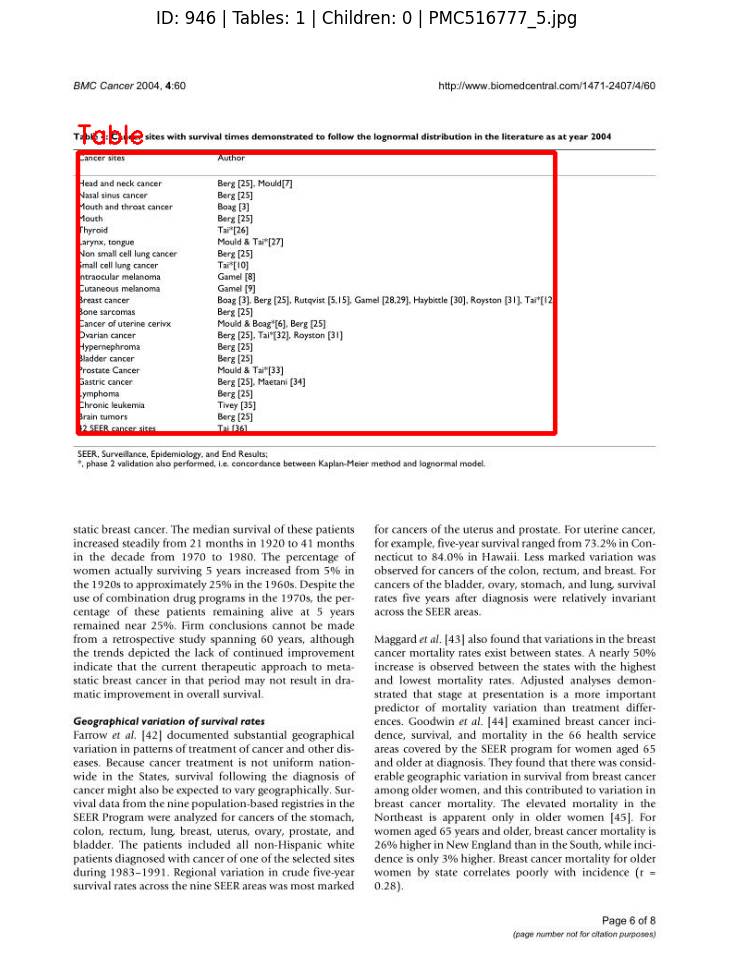

Displaying: ID: 1258 | Tables: 1 | Children: 0 | PMC6250030_2.jpg


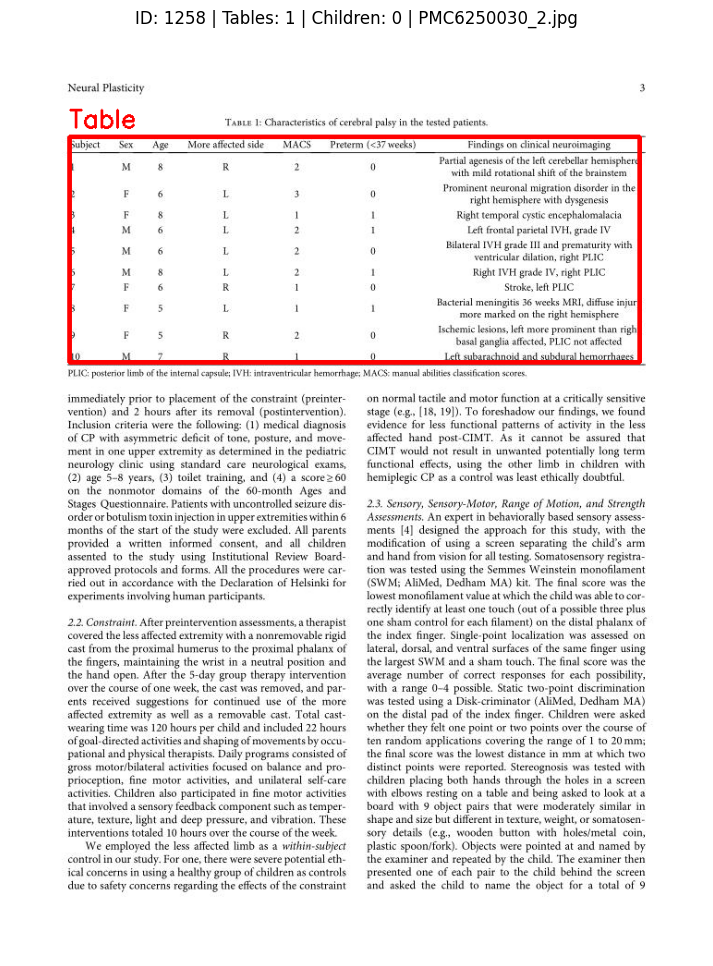

Displaying: ID: 1259 | Tables: 1 | Children: 0 | PMC6251181_4.jpg


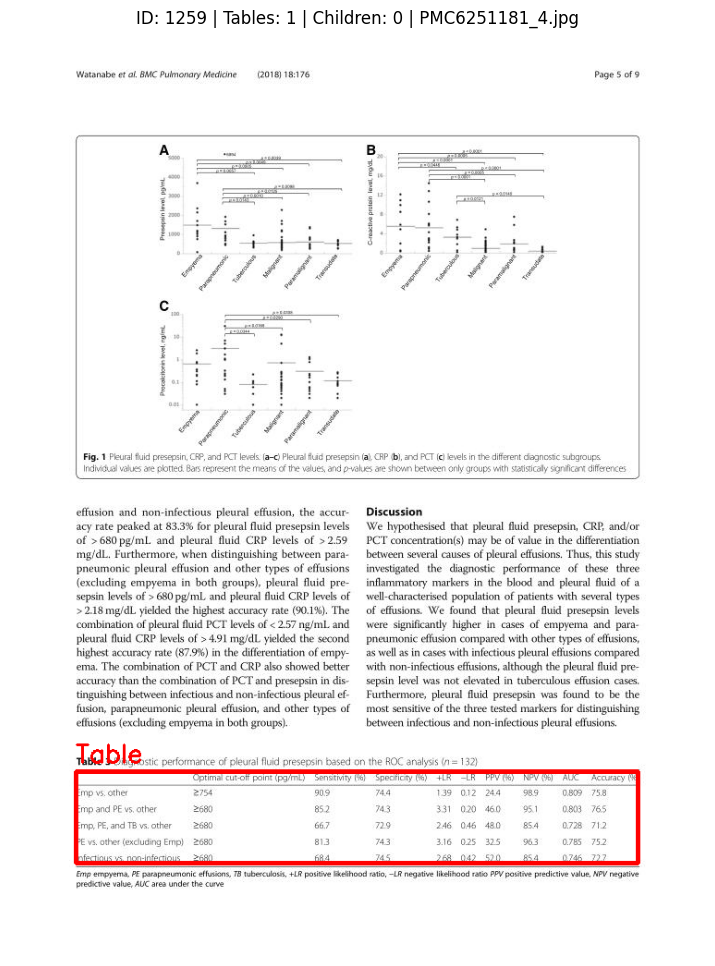

Displaying: ID: 1260 | Tables: 1 | Children: 0 | PMC6251211_6.jpg


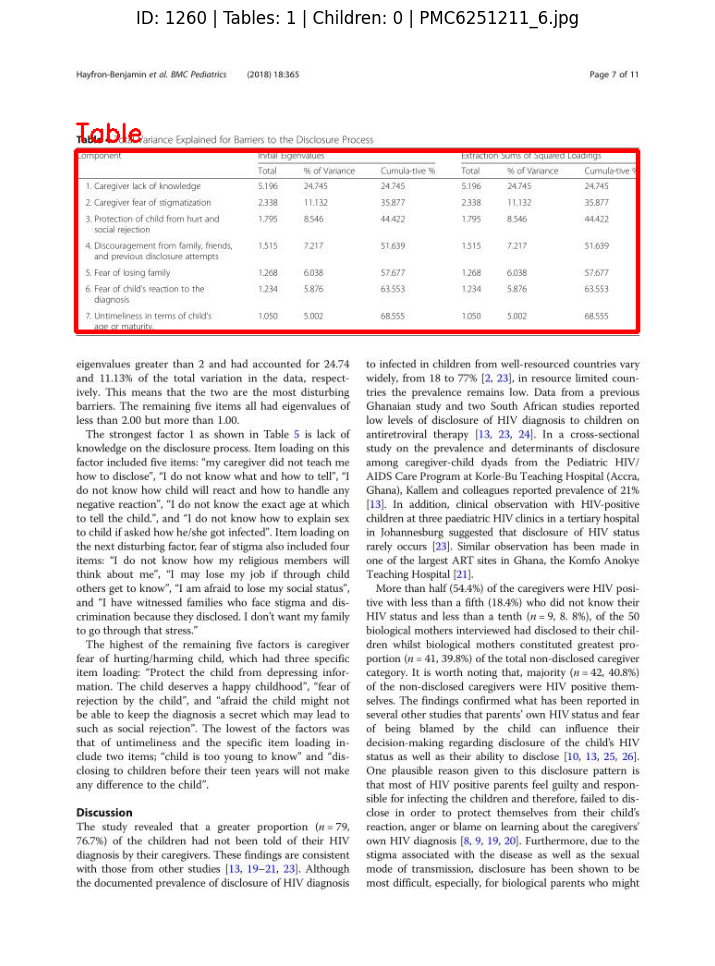

Displaying: ID: 1261 | Tables: 2 | Children: 0 | PMC6251227_5.jpg


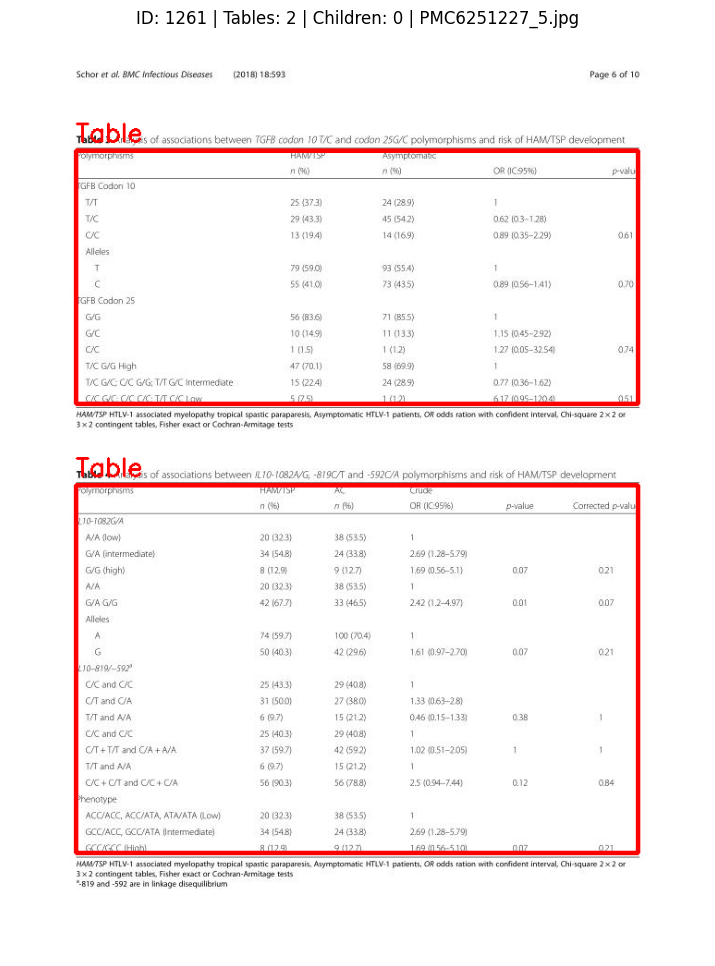

In [6]:
def display_image_with_annotations(image_path, annotations, title=""):
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw annotations
    for ann in annotations:
        bbox = ann['bbox']
        x, y, w, h = map(int, bbox)
        cat_id = ann['category_id']
        
        # Color based on category: Red for Table (1), Green for others
        # Assuming cat_id 1 is Table based on previous context
        if cat_id == 1: 
            color = (255, 0, 0) # Red for Table
            label = "Table"
        else:
            color = (0, 255, 0) # Green for Child
            label = f"Cat {cat_id}"
            
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        cv2.putText(img_rgb, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Create a quick lookup for annotations by image_id
# We need this to pass the specific annotations to the display function
from collections import defaultdict
image_annotations_map = defaultdict(list)
if coco_data:
    for ann in coco_data['annotations']:
        image_annotations_map[ann['image_id']].append(ann)

# Display problematic images with bounding boxes
if not df_prob.empty:
    print(f"Displaying 5 sample images out of {len(df_prob)}...")
    
    count = 0 
    for _, row in df_prob.iterrows():
        if count >= 5:
            break
        
        fname = row['file_name']
        img_id = row['image_id']
        full_path = os.path.join(IMAGES_DIR, fname)
        
        # Get annotations for this image
        current_anns = image_annotations_map[img_id]
        
        title_text = f"ID: {img_id} | Tables: {row['table_count']} | Children: {row['child_count']} | {fname}"
        print(f"Displaying: {title_text}")
        display_image_with_annotations(full_path, current_anns, title_text)
        count += 1
else:
    print("No images to display.")

In [7]:
# ---------------------------------------------------------
# ORPHAN CHECK: Images with Child Annotations but NO Table Animations
# ---------------------------------------------------------

orphaned_images = []

if coco_data:
    for img_id, counts in img_to_anns.items():
        # Condition: No table annotations, but has child annotations
        if counts['tables'] == 0 and counts['children'] > 0:
            orphaned_images.append({
                'image_id': img_id,
                'file_name': counts['file_name'],
                'table_count': counts['tables'],
                'child_count': counts['children']
            })

print(f"Found {len(orphaned_images)} images with child annotations but NO table parent.")

# Convert to DataFrame
df_orphan = pd.DataFrame(orphaned_images)

if not df_orphan.empty:
    print("List of orphaned images (head):")
    print(df_orphan.head())
    
    # Save to CSV
    orphan_csv_path = os.path.join(OUTPUT_DIR, 'orphaned_images_missing_table.csv')
    df_orphan.to_csv(orphan_csv_path, index=False)
    print(f"Saved orphaned images list to: {orphan_csv_path}")
    
    # Display ALL orphaned images as requested
    print(f"Displaying ALL {len(df_orphan)} orphaned images...")
    for _, row in df_orphan.iterrows():
        fname = row['file_name']
        img_id = row['image_id']
        full_path = os.path.join(IMAGES_DIR, fname)
        
        current_anns = image_annotations_map[img_id]
        
        title_text = f"ORPHAN | ID: {img_id} | No Table Parent | Children: {row['child_count']} | {fname}"
        display_image_with_annotations(full_path, current_anns, title_text)
else:
    print("No orphaned images (children without table) found.")

Found 0 images with child annotations but NO table parent.
No orphaned images (children without table) found.
